# Flowers Classification

We are going to use the Flowers dataset from Keras

(The other workbook uses [Beans dataset](https://www.tensorflow.org/datasets/catalog/beans) from TensorFlow Datasets, but that has gone down so no longer works!)

The goal for today is:
1. Build a simple CNN from scratch and see what accuracy we can get
2. Apply transfer learning using a pre-trained model and compare the result

**Important:** Today we are using the validation set to compare models. We will **not** touch the test set until the very end, after we have chosen our best model.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers
import pathlib

2026-04-17 16:45:35.048994: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-17 16:45:35.055750: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776440735.063989   42807 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776440735.066604   42807 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-17 16:45:35.074580: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

## Loading the Data

Some datasets in TensorFlow Datasets come with pre-defined splits. 

Beans already has `train`, `validation`, and `test` splits, so we can load all three directly.

If a dataset only has a `train` split, you would have to create your own test and validation sets manually — as you will be doing in the project.

Flowers only has one set, so we will have to make train/test/val ourselves

In [2]:
# This will download the dataset on the first run -- run this cell now
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file(
    "flower_photos",
    origin=dataset_url,
    untar=True
)

data_dir = pathlib.Path(data_dir)

In [3]:
# Now to split it into training and validation

img_height = 150
img_width = 150
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 3670 files belonging to 1 classes.
Using 2936 files for training.


I0000 00:00:1776440737.301319   42807 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1055 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 3670 files belonging to 1 classes.
Using 734 files for validation.


If it only says 1 class that's wrong

In [4]:
data_dir

PosixPath('/home/matthew/.keras/datasets/flower_photos')

We need one more nested folder so

In [5]:
import os
data_dir = os.path.join(data_dir, "flower_photos")
data_dir

'/home/matthew/.keras/datasets/flower_photos/flower_photos'

Try again

In [6]:
# Now to split it into training and validation
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    batch_size=batch_size
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


We need a separate test set, let's split validation again

In [7]:
val_batches = tf.data.experimental.cardinality(validation_ds)

test_ds = validation_ds.take(val_batches // 2)
validation_ds = validation_ds.skip(val_batches // 2)

In [8]:
test_ds = test_ds.cache()                                                                                                                   
validation_ds = validation_ds.cache()

## Data Exploration

Before building any model, always understand your data first.

This will tell us the number of batches, each batch has size 32

In [9]:
print(f"Training samples:   {train_ds.cardinality()}")
print(f"Validation samples: {validation_ds.cardinality()}")
print(f"Test samples:       {test_ds.cardinality()}")

Training samples:   92
Validation samples: 12
Test samples:       11


In [10]:
train_images = len(list(train_ds.unbatch()))
train_images

2026-04-17 16:45:38.414026: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2936

### Class Distribution

Is the dataset balanced? An imbalanced dataset means accuracy alone can be misleading.

**Task:** Extract the labels from `train_ds` and plot a bar chart showing how many images there are per class. The class names are `['angular_leaf_spot', 'bean_rust', 'healthy']` (labels 0, 1, 2).

In [11]:
class_names = train_ds.class_names

num_classes = len(class_names)
print(class_names)



['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


2026-04-17 16:45:38.704095: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


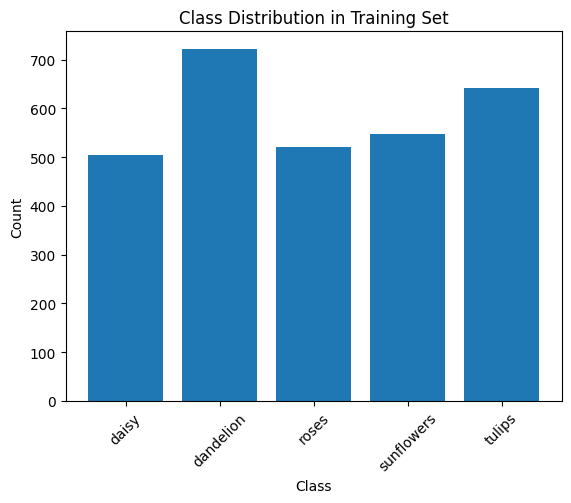

In [12]:
# Extract all labels from the training set
train_labels = np.array([y.numpy() for x, y in train_ds.unbatch()])
# --- Your code here ---
# Plot a bar chart of class counts
# Hint: use np.unique with return_counts=True, then plt.bar
unique, counts = np.unique(train_labels, return_counts=True)
plt.bar(unique, counts)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution in Training Set')
plt.xticks(unique, class_names, rotation=45)
plt.show()



In [13]:
train_labels

array([3, 3, 4, ..., 3, 4, 2], dtype=int32)

### Sample Images

Let's look at some examples. Can you see visual differences between the classes?

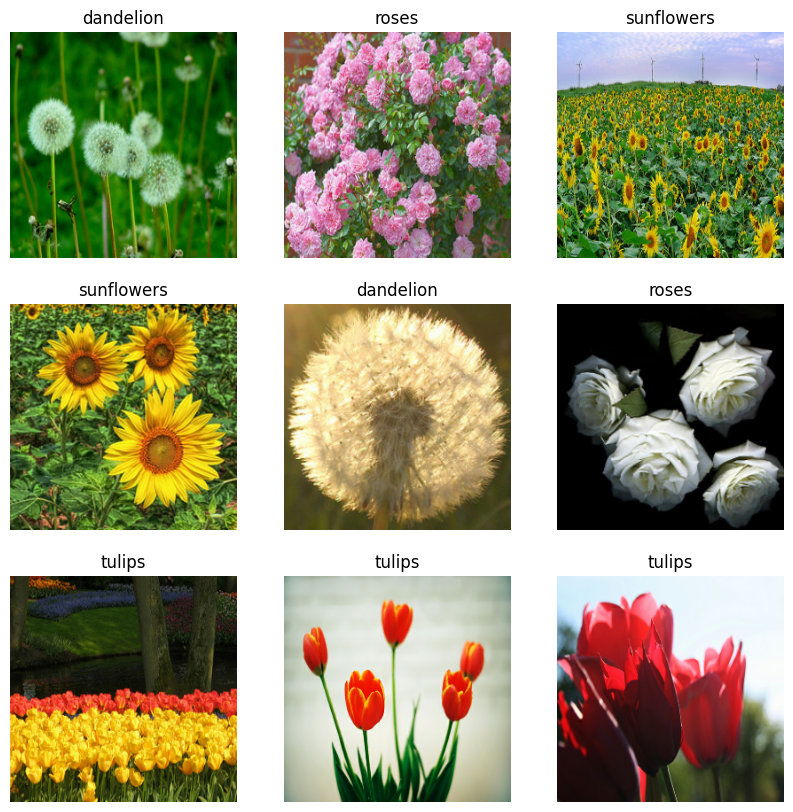

In [14]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

**Task:** What are the original image dimensions? Write a line of code to print the shape of one image from the training set.

In [15]:
# --- Your code here ---
# Print the shape of the first image in train_ds
for images, labels in train_ds.take(1):
    print("Shape of the first image:", images[0].shape)


Shape of the first image: (256, 256, 3)


2026-04-17 16:45:39.130195: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Part 1 — CNN from Scratch

We will resize all images to $150 \times 150$ to keep training fast. The Rescaling layer inside the model will normalise pixel values to $[0, 1]$ at training time.

We keep a copy of the original datasets so we can easily try a different size later for the transfer learning part. We could have specified an image_size when we used dataset_from_directory but this may be more useful if we want to try different image sizes

In [16]:
IMAGE_SIZE = 150
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

train150_ds = train_ds.map(
    lambda x, y: (tf.image.resize(x, [IMAGE_SIZE, IMAGE_SIZE]), y)
).prefetch(AUTOTUNE)

validation150_ds = validation_ds.map(lambda x, y: (tf.image.resize(x, [IMAGE_SIZE, IMAGE_SIZE]), y)).prefetch(AUTOTUNE)

test150_ds = test_ds.map(lambda x, y: (tf.image.resize(x, [IMAGE_SIZE, IMAGE_SIZE]), y)).prefetch(AUTOTUNE)


### Model Definition

A straightforward CNN: three Conv+Pool blocks, then GlobalAveragePooling2D to collapse the spatial dimensions, one Dense hidden layer, and a 3-unit output.

A few things to note:
- The output layer has **no activation**. We use `from_logits=True` in the loss function, which is numerically more stable than applying softmax and then computing log-loss.
- We are not using BatchNormalization here to keep the model simple. You would typically add it in a production model.
- We are keeping the architecture modest intentionally — you may well see signs of underfitting, which is the motivation for trying transfer learning.

In [17]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    layers.Rescaling(1./255),

    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes)   # no activation -- from_logits=True in loss
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,549 (127.14 KB)

 Trainable params: 32,549 (127.14 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

### Training

We train for 20 epochs. Early stopping could be used here to automatically find a good stopping point, but the focus of today is on comparing scratch vs transfer learning, so we keep it simple.

Watch both `accuracy` and `val_accuracy` as it trains. What do you notice about the gap between them?

In [19]:
history = model.fit(
    train150_ds,
    validation_data=validation150_ds,
    epochs=20
)

Epoch 1/20


I0000 00:00:1776440739.880646   43013 service.cc:148] XLA service 0x77d068006380 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776440739.880678   43013 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4080, Compute Capability 8.9
2026-04-17 16:45:39.908700: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776440740.028953   43013 cuda_dnn.cc:529] Loaded cuDNN version 91002


34/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2443 - loss: 1.5896

I0000 00:00:1776440741.606009   43013 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.3573 - loss: 1.4361 - val_accuracy: 0.4869 - val_loss: 1.2556
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4748 - loss: 1.2210 - val_accuracy: 0.4921 - val_loss: 1.1902
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5252 - loss: 1.1444 - val_accuracy: 0.5576 - val_loss: 1.0875
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5542 - loss: 1.0960 - val_accuracy: 0.5969 - val_loss: 1.0607
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5814 - loss: 1.0525 - val_accuracy: 0.5864 - val_loss: 1.0280
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5800 - loss: 1.0404 - val_accuracy: 0.5995 - val_loss: 1.0371
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5960 - loss: 1.0092 - val_accuracy: 0.6283 - val_loss: 0.9531
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6216 - loss: 0.9710 - val_accuracy: 0.6440 - val_loss: 0.9293
Ep

### Plotting Training History

**Task:** Plot the training and validation accuracy and loss curves. What do the curves tell you about overfitting or underfitting?

- If training accuracy is much higher than validation accuracy: overfitting
- If both are low and close together: underfitting

Note the final **validation accuracy** — this is the number you will compare against the transfer learning model.

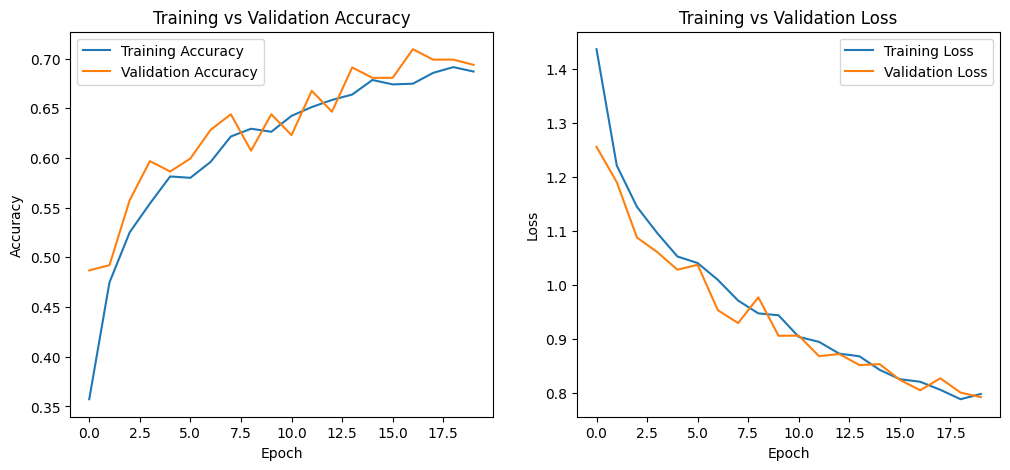

In [20]:
# --- Your code here ---
# Plot training vs validation accuracy
# Plot training vs validation loss
# (two separate plots, or two subplots side by side)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

**Discussion:** If training accuracy is below around 80%, the model is likely underfitting -- a deeper network or more epochs might help. We could also add BatchNormalization or data augmentation. We are going to move on to transfer learning to address this more effectively, but it is worth knowing that improving the scratch model further is a valid path too.

---

## Part 2 — Transfer Learning

Now we will use **Xception** pre-trained on ImageNet as a base model. Xception was trained on millions of images and has already learned to detect edges, textures, and shapes that are useful for almost any image classification task.

The plan:
1. Load Xception with the top (classifier) layers removed
2. Freeze the base model weights
3. Add our own classifier head on top
4. Train only the new head
5. Fine-tune: unfreeze part of the base model and train again at a very low learning rate

Refer to the transfer learning lecture notes and the [Keras guide](https://keras.io/guides/transfer_learning/) for the API.

### Step 1 — Image Size

Xception has a minimum input size. Look it up in the [Keras documentation](https://keras.io/api/applications/xception/) before continuing.

**Task:** Create resized and batched versions of the three datasets for use with Xception. Choose an appropriate image size. Use the same pipeline pattern as above (`.map`, `.batch`, `.prefetch`). Call them `train_xc_ds`, `validation_xc_ds`, `test_xc_ds`.

In [21]:
# --- Your code here ---
# XC_SIZE = ?   # check the Keras docs for Xception minimum input size
# Create train_xc_ds, validation_xc_ds, test_xc_ds
from tensorflow.keras.applications import Xception

XC_SIZE = 150
train_xc_ds = train_ds.map(lambda x, y: (tf.image.resize(x, [XC_SIZE, XC_SIZE]), y)).prefetch(AUTOTUNE)
validation_xc_ds = validation_ds.map(lambda x, y: (tf.image.resize(x, [XC_SIZE, XC_SIZE]), y)).prefetch(AUTOTUNE)
test_xc_ds = test_ds.map(lambda x, y: (tf.image.resize(x, [XC_SIZE, XC_SIZE]), y)).prefetch(AUTOTUNE)


### Step 2 — Load the Base Model

**Task:** Load Xception with:
- `include_top=False` (removes the ImageNet classifier head)
- `weights='imagenet'` (loads pre-trained weights)
- The correct `input_shape` for your chosen image size

Then freeze it. Check the lecture notes for the one-line freeze call.

In [22]:
# --- Your code here ---
# base_model = tf.keras.applications.Xception(...)
# freeze it
# print how many trainable and non-trainable parameters it has

base_model = tf.keras.applications.Xception(
    weights='imagenet',
    input_shape=(XC_SIZE, XC_SIZE, 3),
    include_top=False
)
base_model.trainable = False

trainable = sum(tf.keras.backend.count_params(p) for p in base_model.trainable_weights)
non_trainable = sum(tf.keras.backend.count_params(p) for p in base_model.non_trainable_weights)
print(f"Trainable parameters:     {trainable:,}")
print(f"Non-trainable parameters: {non_trainable:,}")

Trainable parameters:     0
Non-trainable parameters: 20,861,480


### Step 3 — Preprocessing

Xception expects inputs normalised in a specific way -- **not** simply divided by 255. It has its own preprocessing function.

**Task:** Find the correct preprocessing function for Xception in the Keras documentation and apply it in the model below.

### Step 4 — Build the New Model

Using the Functional API (required here because we are grafting onto an existing model), build a model that:
1. Takes an input of your chosen image size
2. Applies the Xception preprocessing function
3. Passes through the frozen base model (`training=False` — check your notes for why this matters with BatchNormalization)
4. Applies `GlobalAveragePooling2D`
5. Adds a `Dense` output layer with 3 units and no activation

Then compile and call `model_tl.summary()`.

In [23]:
# --- Your code here ---
# Build model_tl using the Functional API
# Compile with Adam, SparseCategoricalCrossentropy(from_logits=True), accuracy

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

inputs = tf.keras.Input(shape=(XC_SIZE, XC_SIZE, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.xception.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(num_classes)(x)
model_tl = tf.keras.Model(inputs, outputs)

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
model_tl.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 5, 5, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │        10,245 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,871,725 (79.62 MB)

 Trainable params: 10,245 (40.02 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

**Look at the summary.** How many trainable parameters does your model have now compared to the scratch CNN? The base model weights are frozen so they are listed as non-trainable.

### Step 5 — Train the Head

Train for 10 epochs. We are only training the new layers on top -- the base model weights are frozen. Early stopping could be used here to find the optimal number of epochs automatically, but we keep it simple for today.

Watch the validation accuracy. How does it compare to the scratch CNN?

In [24]:
# --- Your code here ---
# history_tl = model_tl.fit(...)
history_tl = model_tl.fit(
    train_xc_ds,
    validation_data=validation_xc_ds,
    epochs=10
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.7190 - loss: 0.7932 - val_accuracy: 0.8063 - val_loss: 0.5385
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8185 - loss: 0.5171 - val_accuracy: 0.8168 - val_loss: 0.4822
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8420 - loss: 0.4602 - val_accuracy: 0.8246 - val_loss: 0.4599
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8515 - loss: 0.4210 - val_accuracy: 0.8351 - val_loss: 0.4289
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8593 - loss: 0.3948 - val_accuracy: 0.8429 - val_loss: 0.4241
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8689 - loss: 0.3778 - val_accuracy: 0.8351 - val_loss: 0.4112
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8787 - loss: 0.3473 - val_accuracy: 0.8403 - val_loss: 0.4045
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8859 - loss: 0.3409 - val_accuracy: 0.8377 - v

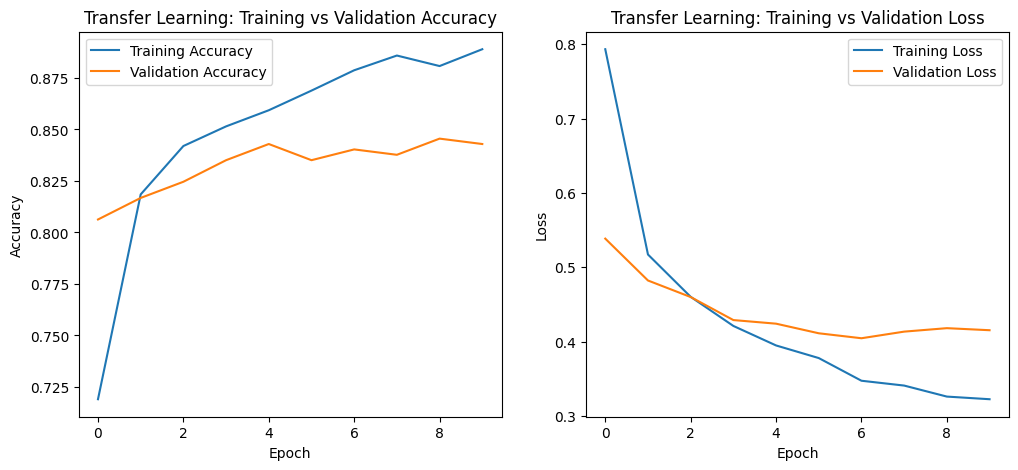

In [25]:
# --- Your code here ---
# Plot training and validation accuracy/loss curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_tl.history['accuracy'], label='Training Accuracy')
plt.plot(history_tl.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Transfer Learning: Training vs Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_tl.history['loss'], label='Training Loss')
plt.plot(history_tl.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Transfer Learning: Training vs Validation Loss')
plt.legend()
plt.show()

### Step 6 — Add a Dense Hidden Layer (Optional Extension)

The classifier head above goes straight from GlobalAveragePooling2D to the output. Try adding a Dense hidden layer (e.g. 256 units, ReLU activation) between the pooling and the output layer. Does it improve validation accuracy?

Rebuild, recompile, and retrain. Record the validation accuracy for each version.

In [26]:
# --- Optional: Your code here ---
# Build model_tl_v2 with an extra Dense layer in the head
inputs = tf.keras.Input(shape=(XC_SIZE, XC_SIZE, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.xception.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes)(x)
model_tl_v2 = tf.keras.Model(inputs, outputs)

model_tl_v2.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history_tl_v2 = model_tl_v2.fit(
    train_xc_ds,
    validation_data=validation_xc_ds,
    epochs=10
)

print(f"\nmodel_tl_v2 final val accuracy: {history_tl_v2.history['val_accuracy'][-1]:.4f}")

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.7224 - loss: 0.7396 - val_accuracy: 0.8037 - val_loss: 0.5015
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8263 - loss: 0.4774 - val_accuracy: 0.8298 - val_loss: 0.4464
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8443 - loss: 0.4305 - val_accuracy: 0.8246 - val_loss: 0.4493
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8604 - loss: 0.3729 - val_accuracy: 0.8403 - val_loss: 0.4374
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8736 - loss: 0.3361 - val_accuracy: 0.8246 - val_loss: 0.4562
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8849 - loss: 0.3239 - val_accuracy: 0.8298 - val_loss: 0.4850
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8879 - loss: 0.2986 - val_accuracy: 0.8508 - val_loss: 0.4213
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9111 - loss: 0.2498 - val_accuracy: 0.8482 - v

### Step 7 — Fine-Tuning

Now unfreeze the top layers of the base model and train the whole model at a **very low learning rate**. This makes small adjustments to the pre-trained weights to better fit our dataset.

**Task:**
1. Set `base_model.trainable = True`
2. Freeze everything up to layer 100 (keep the early feature-detector layers frozen)
3. Recompile with a learning rate of `1e-5`
4. Train for 10 more epochs

Check your lecture notes for the fine-tuning code pattern. Make sure you recompile after changing which layers are trainable -- Keras requires this.

In [27]:
# --- Your code here ---
# Unfreeze base_model
# Freeze layers[:100]
# Recompile with learning_rate=1e-5
# Fit for 10 more epochs
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history_ft = model_tl.fit(
    train_xc_ds,
    validation_data=validation_xc_ds,
    epochs=10
)

Epoch 1/10
 3/92 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7795 - loss: 0.8938

2026-04-17 16:46:52.526570: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 6.77GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-17 16:46:52.554195: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.39GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-17 16:46:52.592142: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.62GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-17 16:46:52.611488: W external/local_xla/xla/ts

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7688 - loss: 0.8197

2026-04-17 16:46:56.059522: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 6.77GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-17 16:46:56.082004: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.39GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-17 16:46:56.111469: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:306] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.62GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-17 16:46:56.128012: W external/local_xla/xla/ts

92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.7919 - loss: 0.7480 - val_accuracy: 0.8377 - val_loss: 0.4430
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8413 - loss: 0.5549 - val_accuracy: 0.8586 - val_loss: 0.4395
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.8668 - loss: 0.4481 - val_accuracy: 0.8586 - val_loss: 0.4204
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.8747 - loss: 0.3990 - val_accuracy: 0.8586 - val_loss: 0.4011
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.8893 - loss: 0.3607 - val_accuracy: 0.8665 - val_loss: 0.3879
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.8917 - loss: 0.3261 - val_accuracy: 0.8665 - val_loss: 0.3787
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9077 - loss: 0.2975 - val_accuracy: 0.8639 - val_loss: 0.3647
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9033 - loss: 0.2869 - val_accuracy: 0.8770 - val_loss: 0.

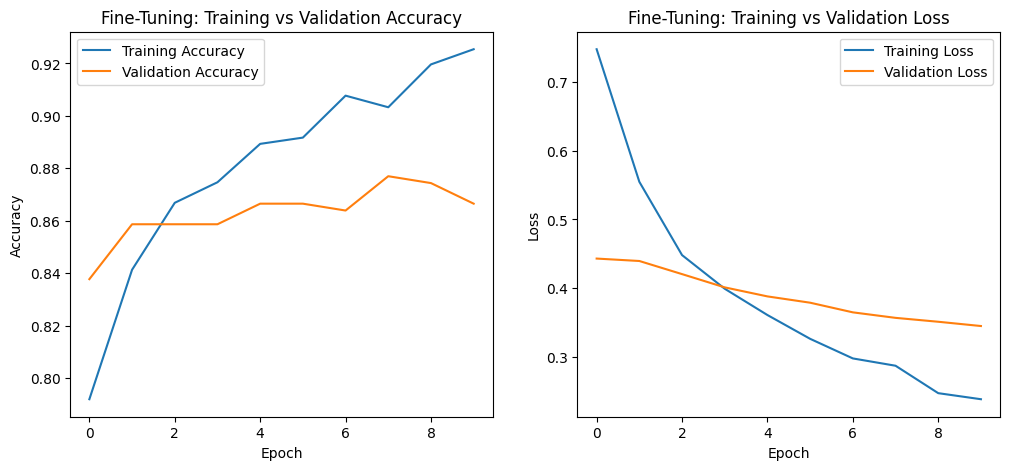

In [28]:
# --- Your code here ---
# Plot the fine-tuning training curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_ft.history['accuracy'], label='Training Accuracy')
plt.plot(history_ft.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Fine-Tuning: Training vs Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_ft.history['loss'], label='Training Loss')
plt.plot(history_ft.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Fine-Tuning: Training vs Validation Loss')
plt.legend()
plt.show()

### Step 8 — Compare Models on the Validation Set

**Task:** Use `model.evaluate()` on `validation_xc_ds` (not the test set) for each model variant you have trained. Record the validation accuracy for:
- Scratch CNN
- Transfer learning (head only)
- Transfer learning (after fine-tuning)

Which is best? **This** is how you choose your final model -- using validation scores, not the test set.

In [29]:
# --- Your code here ---
# Evaluate each model on the validation set and print the results
# You will need to evaluate the scratch CNN on validation150_ds
# and the transfer learning model on validation_xc_ds
scratch_loss, scratch_acc = model.evaluate(validation150_ds, verbose=0)
tl_head_acc = history_tl.history['val_accuracy'][-1]
tl_ft_loss, tl_ft_acc = model_tl.evaluate(validation_xc_ds, verbose=0)

print(f"Scratch CNN validation accuracy:              {scratch_acc:.4f}")
print(f"Transfer learning (head only) val accuracy:   {tl_head_acc:.4f}")
print(f"Transfer learning (fine-tuned) val accuracy:  {tl_ft_acc:.4f}")

Scratch CNN validation accuracy:              0.6937
Transfer learning (head only) val accuracy:   0.8429
Transfer learning (fine-tuned) val accuracy:  0.8665


### Step 9 — Final Evaluation on the Test Set

Now that you have chosen your best model based on validation performance, evaluate it **once** on the test set. This is your honest estimate of how well the model will perform on unseen data.

Do not go back and change your model after seeing the test score.

In [30]:
# --- Your code here ---
# Evaluate your chosen best model on the appropriate test dataset
test_loss, test_acc = model_tl.evaluate(test_xc_ds, verbose=0)
print(f"Final test accuracy (fine-tuned transfer learning): {test_acc:.4f}")

Final test accuracy (fine-tuned transfer learning): 0.8807
